### Figure 3A

In [ ]:
import scipy.stats as stats
import pandas as pd

In [34]:
# select only discovery columns
# load abundance and annotation
data = pd.read_csv("SelectedProteins(IBDDiscoveryValidationBatchCorrection).csv", sep=";", index_col=0)#

# load annotation data 
annotation = pd.read_csv("Annotations.csv", sep=";", index_col=0)

#print(type(data.loc["Meta-Protein 7357"]["P02_C"]))
for row in data.index:
    if row.startswith("Meta-Protein"):
        data.loc[row]=data.loc[row].astype(float)
print(type(data.loc["Meta-Protein 7357"]["P02_C"]))
data.replace(["CD","UC","UCr","UCa","IBD-ND-OS","IBD-ND","UC-OS","CD-OS"],"IBD",inplace=True) # if all IBD case should be summarized
data.replace("normal","control",inplace=True) # if all IBD case should be summarized
# Zugriff auf Zeile 4 (UseCase)
row = data.loc["UseCase"]

discovery_columns = row[row == 'BiomarkerDiscovery'].index
validation_columns = row[row == 'BiomarkerValidation'].index
specificity_columns = row[row == 'DiseaseSpecificity'].index

# Zeige nur die Spalten mit dem Wert "BiomarkerDiscovery", "BiomarkerValidation" oder "DiseaseSpecificity"
df_discovery = data[discovery_columns]
df_validation = data[validation_columns]
df_specificity = data[specificity_columns]

UseCaseSpecData={"discovery":df_discovery,"validation":df_validation,"specificity":df_specificity}

<class 'str'>
<class 'float'>


In [36]:
# for each metaprotein use the columns with disease = IBD and disease = control
# calculate p-value and fold change and apend those columns
row = df_discovery.loc["disease"]

control_columns = row[row == 'control'].index
IBD_columns = row[row == 'IBD'].index

df_control = df_discovery[control_columns]
df_IBD = df_discovery[IBD_columns]

#control=np.asarray(df_control.loc["Meta-Protein 35632"]).astype(float)
#diseased=np.asarray(df_IBD.loc["Meta-Protein 35632"]).astype(float)
#t_stat1, p_value1 = stats.mannwhitneyu(control, diseased)
average_control=[]
average_diseased=[]
p_values=[]
annotations=[]
df_discovery= df_discovery.drop(["condition","disease","disease_state","study","UseCase"])
for metaprotein in df_discovery.index:
    control=np.asarray(df_control.loc[metaprotein]).astype(float)
    diseased=np.asarray(df_IBD.loc[metaprotein]).astype(float)
    t_stat1, p_value1 = stats.mannwhitneyu(control, diseased)
    p_values.append(p_value1)
    average_diseased.append(np.average(diseased))
    average_control.append(np.average(control))
    if "Homo sapiens" in str(annotation.loc[metaprotein,"Taxonomy"]):
        annotations.append("Homo sapiens")
    else:
        annotations.append("Microbiome")

corr_p_values= stats.false_discovery_control(p_values, axis=0, method='bh')
df_discovery.insert(0,"average(diseased)", average_diseased)
df_discovery.insert(0,"average(control)", average_control)
df_discovery.insert(0,"p-value", corr_p_values)
df_discovery.insert(0,"TaxonomicAnnotation", annotations)
#df_discovery.loc["average(control)"]=average_control 
#df_discovery.loc["average(diseased)"]=average_diseased
#df_discovery.loc["p-value"]= p_values


6.986478955410618
-5.37219129765998
5.822065796175515


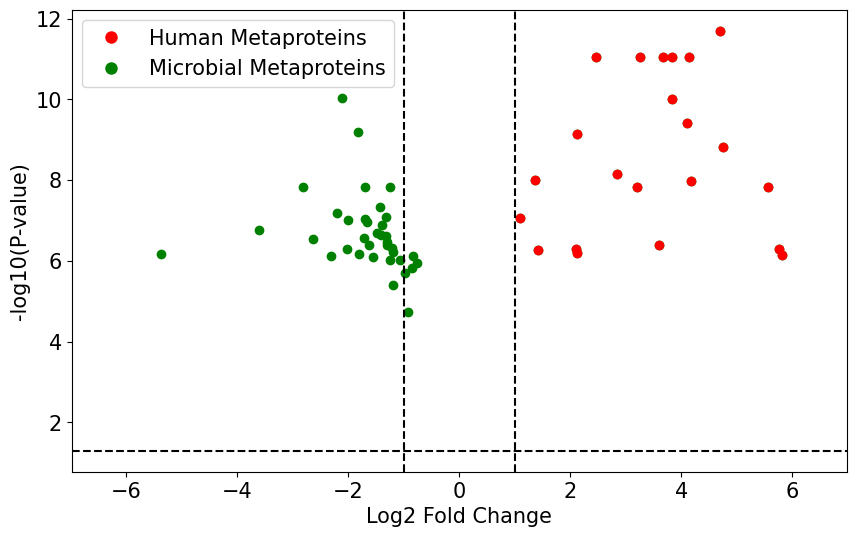

In [43]:
# Calculate log2 fold change
i=0
dfList=[df_discovery]
for df in dfList:
    i+=1
    df['Log2FoldChange'] = np.log2(df.iloc[:, 3] / df.iloc[:, 2])

    # Calculate -log10(p-value)
    df['-log10_Pvalue'] = -np.log10(df.iloc[:, 1])

    # Set significance thresholds (you can adjust these as needed)
    fold_change_threshold = 1.0
    significance_threshold = -np.log10(0.05)
    #xlim1=max(abs())

    # Filter significant features
    significant_df = df[(abs(df['Log2FoldChange']) > fold_change_threshold) & (df['-log10_Pvalue'] > significance_threshold)]

    # Select the human proteins
    human_df = df[abs(df['TaxonomicAnnotation'] == "Homo sapiens")]

    #plt.xlim=
    #print(max(abs(significant_df['Log2FoldChange'])))
    #print(abs(min(np.array(significant_df['Log2FoldChange'])))
    a = np.array(df['Log2FoldChange'])
    min_value = a[np.isfinite(a)].min()
    max_value = a[np.isfinite(a)].max()
    xlimit=max([abs(min_value),abs(max_value)])*1.2
    print(xlimit)
    print(min_value)
    print(max_value)
    
    # Plotting the volcano plot
    plt.figure(figsize=(10, 6))
    plt.xlim(-xlimit,xlimit)
    plt.scatter(df['Log2FoldChange'], df['-log10_Pvalue'], color='green')
    plt.scatter(human_df['Log2FoldChange'], human_df['-log10_Pvalue'], color='red', label='p-value <0.05 and log2 Fold-Change >2')
    
    
    plt.axhline(y=-np.log10(0.05), color='black', linestyle='--')
    plt.axvline(x=fold_change_threshold, color='black', linestyle='--')
    plt.axvline(x=-fold_change_threshold, color='black', linestyle='--')

    line1 = lines.Line2D([], [], color="white", marker='o', markerfacecolor="red", markersize = 10)
    line2 = lines.Line2D([], [], color="white", marker='o', markerfacecolor="green", markersize = 10)
    plt.legend((line1, line2), ('Human Metaproteins', 'Microbial Metaproteins'), fontsize = 15, numpoints=1, loc=0)

    
    plt.xticks(fontsize= 15)
    plt.yticks(fontsize= 15)
    #plt.title('Volcano Plot')
    plt.xlabel('Log2 Fold Change', fontsize=15)
    plt.ylabel('-log10(P-value)',fontsize=15)
    #plt.legend()
    
    plt.savefig(f'VolcanoPlot{i}.png', dpi=500)
    plt.show()